<a href="https://colab.research.google.com/github/Vishal-Mungal/NNDLPRACTICAL/blob/main/NNDL_PR_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.20.0
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


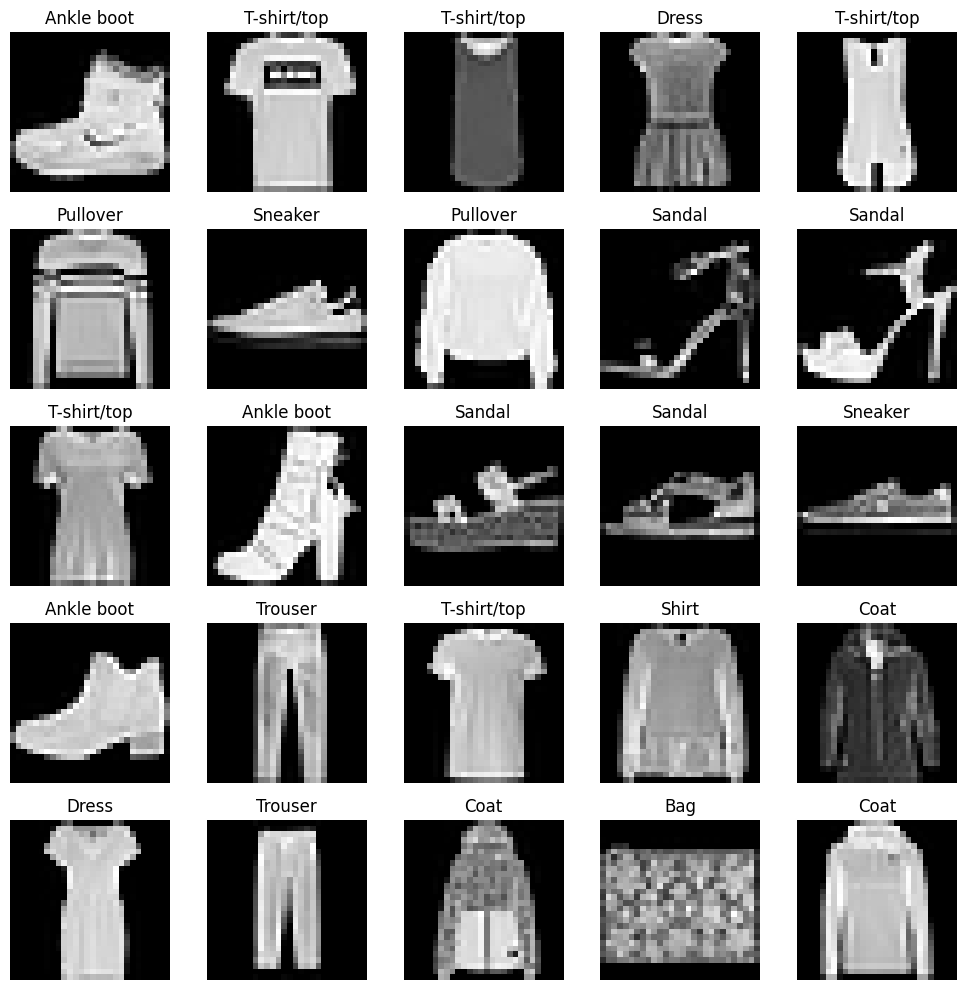

T-shirt/top : 6000
Trouser : 6000
Pullover : 6000
Dress : 6000
Coat : 6000
Sandal : 6000
Shirt : 6000
Sneaker : 6000
Bag : 6000
Ankle boot : 6000
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

class_names = [
"T-shirt/top",
"Trouser",
"Pullover",
"Dress",
"Coat",
"Sandal",
"Shirt",
"Sneaker",
"Bag",
"Ankle boot"
]

print(class_names)
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()
unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(class_names[label], ":", count)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)
model = keras.Sequential([
keras.Input(shape=(28, 28, 1)), # Recommended way to specify input shape

# First Convolutional Layer
layers.Conv2D(
32,
(3, 3),
activation="relu"
),

# First Pooling Layer
layers.MaxPooling2D((2, 2)),

# Second Convolutional Layer
layers.Conv2D(
64,
(3, 3),
activation="relu"
),

# Second Pooling Layer
layers.MaxPooling2D((2, 2)),

# Convert feature maps into a vector
layers.Flatten(),

# Fully connected layer
layers.Dense(128, activation="relu"),

# Dropout to reduce overfitting
layers.Dropout(0.5),

# Output layer - 10 categories
layers.Dense(10, activation="softmax")
])

model.summary()

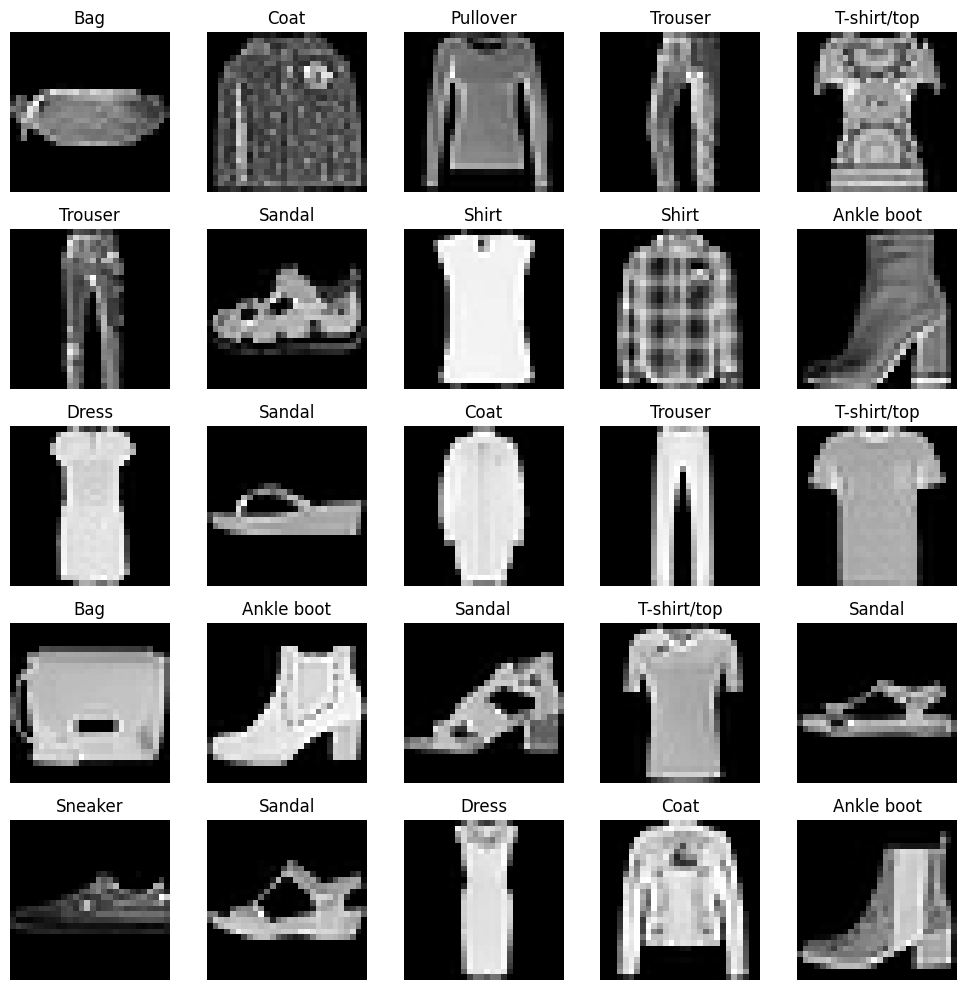

In [10]:
plt.figure(figsize=(10, 10))
for i in range(25):
    # Select a random index for a new image
    random_index = np.random.randint(0, len(x_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[random_index], cmap="gray")
    plt.title(class_names[y_train[random_index]])
    plt.axis("off")

plt.tight_layout()
plt.show()

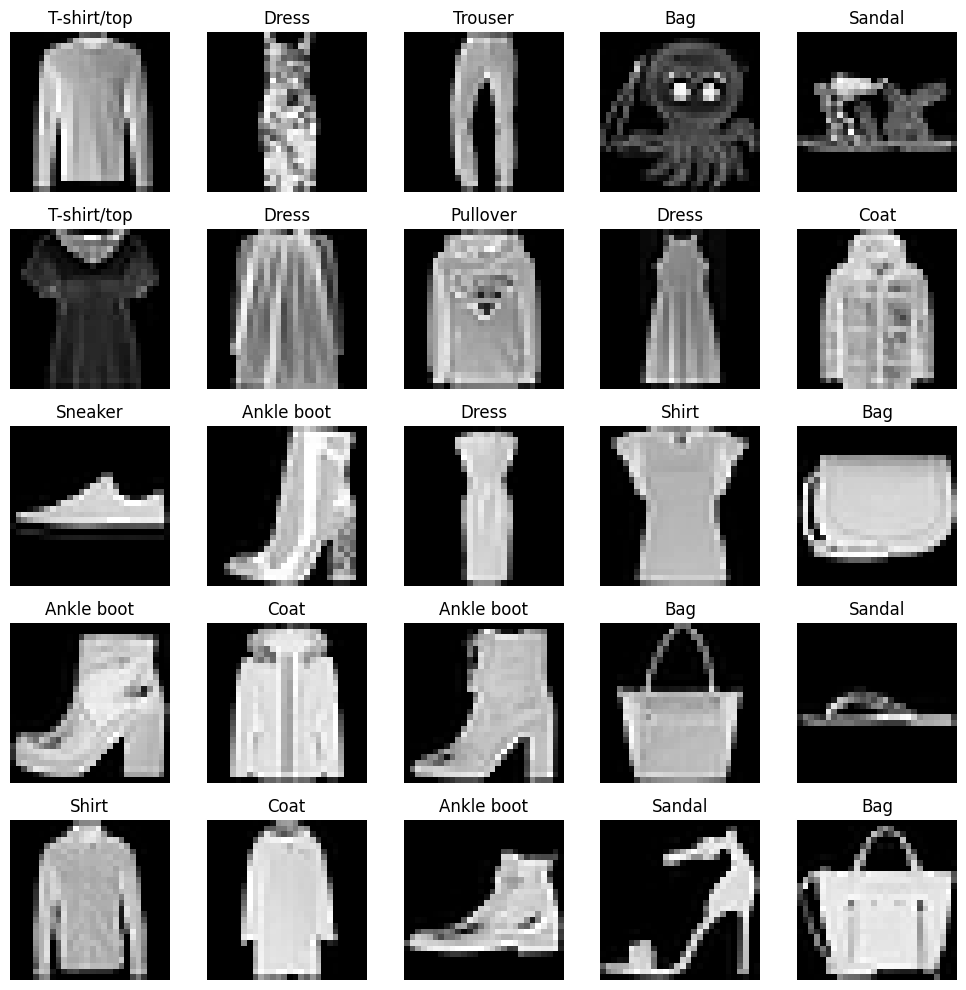

In [11]:
plt.figure(figsize=(10, 10))
for i in range(25):
    # Select a new random index for each image
    random_index = np.random.randint(0, len(x_train))
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[random_index], cmap="gray")
    plt.title(class_names[y_train[random_index]])
    plt.axis("off")

plt.tight_layout()
plt.show()